In [81]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the data

In [88]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [89]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [90]:
### SOLUTION
def calculate_mse(e):
    """Calculate the mse for vector e."""
    return 1 / 2 * np.mean(e**2)


def calculate_mae(e):
    """Calculate the mae for vector e."""
    return np.mean(np.abs(e))


### TEMPLATE
### END SOLUTION


def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    ### SOLUTION
    e = y - tx.dot(w)
    return calculate_mse(e)
    ### TEMPLATE
    # # ***************************************************
    # # INSERT YOUR CODE HERE
    # # TODO: compute loss by MSE
    # # ***************************************************
    # raise NotImplementedError
    ### END SOLUTION

In [84]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    n = y.shape[0]
    l = 1/n * np.mean((y - tx @ w) ** 2)
    return l 

In [79]:
### Test to compare the loss function with the one implemented in numpy

assert np.isclose(compute_loss(y, tx, w), np.mse(y, tx @ w)), "The loss function is not correct"


NameError: name 'w' is not defined

# 2. Grid Search

Fill in the function `grid_search()` below:

In [91]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************
    for i, w0 in enumerate(grid_w0):
        for j, w1 in enumerate(grid_w1):
            w = np.array([w0, w1])
            losses[i, j] = compute_loss(y, tx, w)
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=42.42448314678248, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.004 seconds


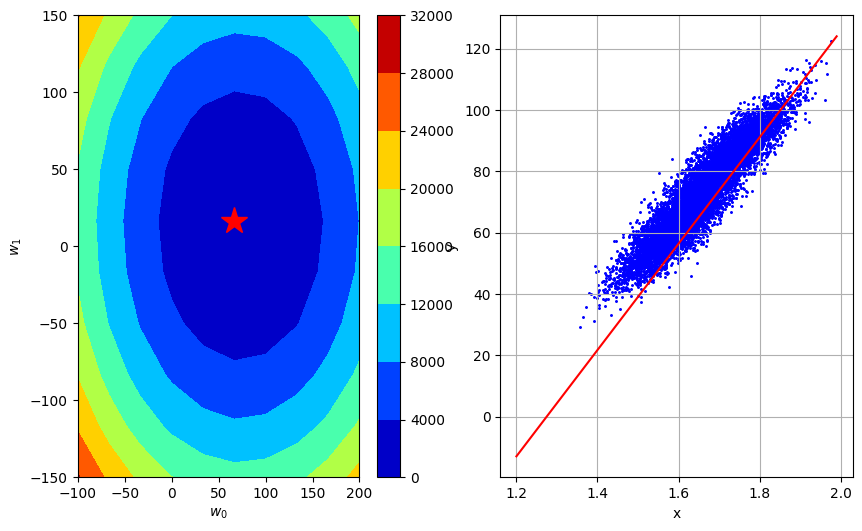

In [92]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

Grid Search: loss*=18.793541019523236, w0*=71.42857142857142, w1*=15.306122448979579, execution time=0.074 seconds


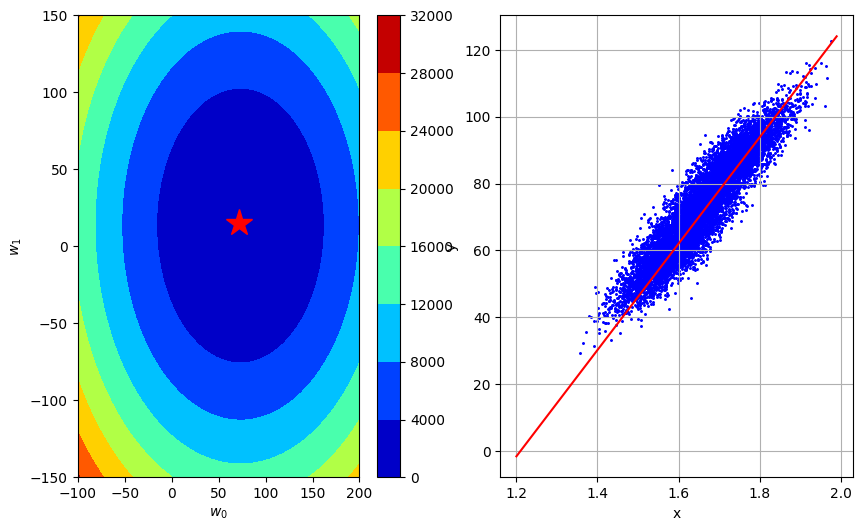

In [93]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=50)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [101]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient vector
    # ***************************************************
    # raise NotImplementedError
    """w0 = -1/len(y) * np.sum(y - tx @ w)
    w1 = -1/len(y) * np.sum((y - tx @ w) * tx[:, 1])
    return np.array([w0, w1])"""

    err = y - tx.dot(w)
    grad = -tx.T.dot(err) / len(err)
    return grad, err

In [95]:
# some intuition 
# case 1: w0 = 100, w1 = 20
print(compute_gradient(y, tx, np.array([100, 20])))
print("Norm case 1: w0 = 100, w1 = 20:", np.linalg.norm(compute_gradient(y, tx, np.array([100, 20]))))

# case 2: w0 = 50, w1 = 10
print(compute_gradient(y, tx, np.array([50, 10])))
print("Norm case 2: w0 = 50, w1 = 10:", np.linalg.norm(compute_gradient(y, tx, np.array([50, 10]))))


# case 3: w0 = 50, w1 = 5
print(compute_gradient(y, tx, np.array([50, 5])))
print("Norm case 3: w0 = 50, w1 = 5:", np.linalg.norm(compute_gradient(y, tx, np.array([50, 5]))))


# case 4: w0 = 100, w1 = 100
print(compute_gradient(y, tx, np.array([100, 100])))
print("Norm case 4: w0 = 100, w1 = 100:", np.linalg.norm(compute_gradient(y, tx, np.array([100, 100]))))

# case 4: w0 = 100, w1 = 100
print(compute_gradient(y, tx, np.array([100, 100])))
print("Norm case 4: w0 = 100, w1 = 100:", np.linalg.norm(compute_gradient(y, tx, np.array([100, 100]))))

print(f"Probably just try to find dome intutition behind it like for examlpe the norm etc the values.. when its closer to the 0 its more precise etc or what are the optimal values etc........")

(array([26.706078  ,  6.52028757]), array([-29.06155218, -38.86177905, -43.66452072, ..., -28.67844694,
       -39.47347627, -25.40914116]))


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

Please fill in the functions `gradient_descent` below:

In [102]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        # ***************************************************
        #gd, _ = compute_gradient(y, tx, w)
        #loss = compute_loss(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        # ***************************************************
        #w = w - gamma * gd

        ### SOLUTION
        # compute loss, gradient
        grad, err = compute_gradient(y, tx, w)
        loss = calculate_mse(err)
        # update w by gradient descent
        w = w - gamma * grad
        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [107]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2792.2367127591674, w0=51.30574540147353, w1=9.435798704492353
GD iter. 1/49: loss=265.30246210896195, w0=66.69746902191568, w1=12.266538315840016
GD iter. 2/49: loss=37.87837955044144, w0=71.31498610804834, w1=13.115760199244335
GD iter. 3/49: loss=17.410212120174467, w0=72.70024123388814, w1=13.370526764265632
GD iter. 4/49: loss=15.568077051450455, w0=73.11581777164007, w1=13.446956733772023
GD iter. 5/49: loss=15.402284895265295, w0=73.24049073296565, w1=13.469885724623941
GD iter. 6/49: loss=15.38736360120863, w0=73.27789262136332, w1=13.476764421879516
GD iter. 7/49: loss=15.38602068474353, w0=73.28911318788263, w1=13.478828031056189
GD iter. 8/49: loss=15.385899822261674, w0=73.29247935783842, w1=13.47944711380919
GD iter. 9/49: loss=15.385888944638305, w0=73.29348920882516, w1=13.47963283863509
GD iter. 10/49: loss=15.3858879656522, w0=73.29379216412119, w1=13.479688556082861
GD iter. 11/49: loss=15.385887877543453, w0=73.29388305071, w1=13.479705271317192
G

In [108]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

In [109]:
# experiment with the value of the step size and initialization parameters
# values for the step size:[0.001, 0.01, 0.5, 1, 2, 2.5]

for gamma in [0.001, 0.01, 0.5, 1, 2, 2.5]:
    max_iters = 50
    w_initial = np.array([0, 0])

    # Start gradient descent.
    start_time = datetime.datetime.now()
    gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
    end_time = datetime.datetime.now()

    # Print result
    exection_time = (end_time - start_time).total_seconds()
    print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2792.2367127591674, w0=0.07329392200210505, w1=0.013479712434989077
GD iter. 1/49: loss=2786.685787960211, w0=0.14651455008220815, w1=0.02694594515754309
GD iter. 2/49: loss=2781.1459594599282, w0=0.21966195753423112, w1=0.04039871164737455
GD iter. 3/49: loss=2775.617205076818, w0=0.29273621757880197, w1=0.053838025370716164
GD iter. 4/49: loss=2770.099502673719, w0=0.3657374033633282, w1=0.06726389978033445
GD iter. 5/49: loss=2764.5928301577246, w0=0.4386655879620701, w1=0.08067634831554316
GD iter. 6/49: loss=2759.0971654800887, w0=0.511520844376213, w1=0.09407538440221658
GD iter. 7/49: loss=2753.612486636144, w0=0.5843032455339421, w1=0.10746102145280331
GD iter. 8/49: loss=2748.1387716652075, w0=0.6570128642905134, w1=0.12083327286633941
GD iter. 9/49: loss=2742.6759986504985, w0=0.7296497734283282, w1=0.13419215202846208
GD iter. 10/49: loss=2737.2241457190466, w0=0.802214045657005, w1=0.1475376723114226
GD iter. 11/49: loss=2731.7831910416035, w0=0.87470575

In [110]:
# experiment with the value of different weights
# values for the step size 0.1 and different weights

weights = [[0,0],[100,10],[-1000,1000]]

for w_initial in [0.001, 0.01, 0.5, 1, 2, 2.5]:
    max_iters = 50
    w_initial = np.array([0, 0])
    gamma = 0.1
    # Start gradient descent.
    start_time = datetime.datetime.now()
    gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
    end_time = datetime.datetime.now()

    # Print result
    exection_time = (end_time - start_time).total_seconds()
    print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2792.2367127591674, w0=7.329392200210505, w1=1.3479712434989077
GD iter. 1/49: loss=2264.635056030004, w0=13.925845180399973, w1=2.561145362647908
GD iter. 2/49: loss=1837.2777140793808, w0=19.8626528625705, w1=3.6530020698820147
GD iter. 3/49: loss=1491.118267099376, w0=25.20577977652397, w1=4.63567310639271
GD iter. 4/49: loss=1210.7291150455724, w0=30.014593999082088, w1=5.520077039252337
GD iter. 5/49: loss=983.6139018819913, w0=34.342526799384395, w1=6.3160405788260015
GD iter. 6/49: loss=799.6505792194906, w0=38.237666319656476, w1=7.032407764442301
GD iter. 7/49: loss=650.640287862865, w0=41.74329188790134, w1=7.6771382314969685
GD iter. 8/49: loss=529.9419518639984, w0=44.898354899321724, w1=8.25739565184617
GD iter. 9/49: loss=432.1762997049164, w0=47.73791160960007, w1=8.779627330160457
GD iter. 10/49: loss=352.9861214560599, w0=50.29351264885059, w1=9.24963584064331
GD iter. 11/49: loss=288.84207707448604, w0=52.59355358417604, w1=9.67264350007788
GD iter

In [111]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 4. Stochastic gradient descent

In [113]:
import random
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    # ***************************************************

    """n = random.randint(0,len(y)-1)
    l_sg = 1/len(y) *np.sum( (y - tx[n] @ w)**2)"""
    e = y - tx @ w
    g = -tx.T @ e / len(y)
    return g,e


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.
        # ***************************************************
        for y_batch,tx_batch in batch_iter(y, tx, batch_size):

            grad, _ = compute_stoch_gradient(y_batch, tx_batch, w)
            w = w - grad*gamma
            ws.append(w)
            loss = compute_loss(y_batch, tx_batch, w)
            losses.append(loss)

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [116]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2214.554917047248, w0=9.395108968285344, w1=13.005903121508124
SGD iter. 1/49: loss=1411.6032576123664, w0=15.681353254110814, w1=8.354084713485733
SGD iter. 2/49: loss=770.1038361090488, w0=20.72110606477267, w1=2.803908210990472
SGD iter. 3/49: loss=1407.9393054989303, w0=26.672631401234483, w1=1.0808098116018738
SGD iter. 4/49: loss=470.99436219017673, w0=30.349293157865702, w1=-1.8885469781387247
SGD iter. 5/49: loss=970.0526799613118, w0=35.29122710688773, w1=-3.3476146753126397
SGD iter. 6/49: loss=1012.0676735353205, w0=40.31076507506031, w1=-2.382796927477485
SGD iter. 7/49: loss=278.83579238092136, w0=43.02749778364363, w1=-3.88941344075607
SGD iter. 8/49: loss=722.7767892300943, w0=47.314143421049295, w1=-2.340917436629785
SGD iter. 9/49: loss=48.73531755219684, w0=48.451736673763826, w1=-2.9858391439845606
SGD iter. 10/49: loss=8.488473312108995, w0=47.91467132253945, w1=-2.3669065958807645
SGD iter. 11/49: loss=104.52843364157042, w0=49.59181329775319, 

In [ ]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 5. Effect of Outliers and MAE Cost Function

In [118]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************

# variables with _1 are those with subsampling and no outliers
height, weight, gender = load_data(sub_sample=True, add_outlier=False)
x_1, mean_x_1, std_x_1 = standardize(height)
y_1, tx_1 = build_model_data(x_1, weight)

# variables with _2 are those with subsampling and outliers
height, weight, gender = load_data(sub_sample=True, add_outlier=True)
x_2, mean_x_2, std_x_2 = standardize(height)
y_2, tx_2 = build_model_data(x_2, weight)

In [119]:
y_1.shape, tx_1.shape


((200,), (200, 2))

In [120]:
y_2.shape, tx_2.shape

((202,), (202, 2))

In [122]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************
gd_losses_1, gd_ws_1 = gradient_descent(
    y_1, tx_1, w_initial, max_iters, gamma
)


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2829.2722244384163, w0=51.54259072181176, w1=10.132993413506084
GD iter. 1/49: loss=267.0500258779429, w0=67.0053679383553, w1=13.172891437557825
GD iter. 2/49: loss=36.45002800750046, w0=71.64420110331838, w1=14.084860844773322
GD iter. 3/49: loss=15.696028199160635, w0=73.03585105280729, w1=14.358451666937965
GD iter. 4/49: loss=13.828168216410077, w0=73.45334603765397, w1=14.440528913587356
GD iter. 5/49: loss=13.660060817962522, w0=73.57859453310797, w1=14.46515208758217
GD iter. 6/49: loss=13.644931152102242, w0=73.61616908174418, w1=14.472539039780616
GD iter. 7/49: loss=13.643569482174817, w0=73.62744144633503, w1=14.474755125440149
GD iter. 8/49: loss=13.643446931881353, w0=73.63082315571229, w1=14.47541995113801
GD iter. 9/49: loss=13.643435902354941, w0=73.63183766852546, w1=14.475619398847368
GD iter. 10/49: loss=13.64343490969756, w0=73.63214202236942, w1=14.475679233160175
GD iter. 11/49: loss=13.643434820358397, w0=73.6322333285226, w1=14.4756971834540

In [ ]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses_1,
        gd_ws_1,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x_1,
        std_x_1,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

In [125]:
# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************
gd_losses_2, gd_ws_2 = gradient_descent(
    y_2, tx_2, w_initial,  max_iters, gamma
)


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2869.8351145358524, w0=51.84746409844842, w1=7.7244264061924195
GD iter. 1/49: loss=318.2821247015965, w0=67.40170332798297, w1=10.041754328050114
GD iter. 2/49: loss=88.6423556165128, w0=72.06797509684336, w1=10.736952704607411
GD iter. 3/49: loss=67.9747763988552, w0=73.46785662750146, w1=10.945512217574597
GD iter. 4/49: loss=66.11469426926604, w0=73.88782108669889, w1=11.00808007146475
GD iter. 5/49: loss=65.94728687760302, w0=74.01381042445813, w1=11.026850427631798
GD iter. 6/49: loss=65.93222021235334, w0=74.0516072257859, w1=11.032481534481914
GD iter. 7/49: loss=65.93086421248087, w0=74.06294626618423, w1=11.034170866536945
GD iter. 8/49: loss=65.93074217249236, w0=74.06634797830372, w1=11.034677666153454
GD iter. 9/49: loss=65.93073118889338, w0=74.06736849193958, w1=11.034829706038408
GD iter. 10/49: loss=65.93073020036948, w0=74.06767464603033, w1=11.034875318003895
GD iter. 11/49: loss=65.93073011140233, w0=74.06776649225755, w1=11.034889001593541
GD it

In [ ]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses_2,
        gd_ws_2,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x_2,
        std_x_2,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 6. Subgradient descent

In [127]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute subgradient gradient vector for MAE
    err = y - tx.dot(w)
    grad = -np.dot(tx.T, np.sign(err)) / len(err)
    return grad, err
    # ***************************************************


In [ ]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute subgradient and loss
        # ***************************************************
        raise NotImplementedError
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        # ***************************************************
        raise NotImplementedError

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [128]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        ### SOLUTION
        # compute loss, gradient
        grad, err = compute_subgradient_mae(y, tx, w)
        loss = calculate_mae(err)
        # gradient w by descent update
        w = w - gamma * grad
        # store w and loss

        ### TEMPLATE
        # # ***************************************************
        # # INSERT YOUR CODE HERE
        # # TODO: compute subgradient and loss
        # # ***************************************************
        # raise NotImplementedError
        # # ***************************************************
        # # INSERT YOUR CODE HERE
        # # TODO: update w by subgradient
        # # ***************************************************
        # raise NotImplementedError
        ### END SOLUTION

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [129]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=73.29392200210518, w0=0.7, w1=-7.798917067702858e-16
SubGD iter. 1/499: loss=72.59392200210517, w0=1.4, w1=-1.5597834135405717e-15
SubGD iter. 2/499: loss=71.89392200210517, w0=2.0999999999999996, w1=-2.3396751203108576e-15
SubGD iter. 3/499: loss=71.19392200210518, w0=2.8, w1=-3.1195668270811434e-15
SubGD iter. 4/499: loss=70.49392200210517, w0=3.5, w1=-3.8994585338514295e-15
SubGD iter. 5/499: loss=69.79392200210518, w0=4.2, w1=-4.679350240621715e-15
SubGD iter. 6/499: loss=69.09392200210517, w0=4.9, w1=-5.459241947392001e-15
SubGD iter. 7/499: loss=68.39392200210519, w0=5.6000000000000005, w1=-6.239133654162287e-15
SubGD iter. 8/499: loss=67.69392200210518, w0=6.300000000000001, w1=-7.0190253609325725e-15
SubGD iter. 9/499: loss=66.99392200210517, w0=7.000000000000001, w1=-7.798917067702859e-15
SubGD iter. 10/499: loss=66.29392200210518, w0=7.700000000000001, w1=-8.578808774473146e-15
SubGD iter. 11/499: loss=65.59392200210519, w0=8.4, w1=-9.358700481243432e-

In [ ]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [131]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic subgradient descent.
        # ***************************************************
        for y_batch, tx_batch in batch_iter(
                    y, tx, batch_size=batch_size, num_batches=1
                ):
            # compute a stochastic subgradient and loss
            grad, err = compute_subgradient_mae(y_batch, tx_batch, w)
            # update w through the stochastic subgradient update
            w = w - gamma * grad
            # calculate loss
            loss = calculate_mae(err)
            # store w and loss
            ws.append(w)
            losses.append(loss)



        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [132]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=69.1499350281692, w0=0.7, w1=-0.02494497508536787
SubSGD iter. 1/499: loss=76.14328661685448, w0=1.4, w1=0.03111617698730652
SubSGD iter. 2/499: loss=77.02199012987248, w0=2.0999999999999996, w1=0.033640774679808416
SubSGD iter. 3/499: loss=63.77491134105023, w0=2.8, w1=-0.2061687287764994
SubSGD iter. 4/499: loss=65.29929909708635, w0=3.5, w1=-0.47232839283651346
SubSGD iter. 5/499: loss=77.82829158173757, w0=4.2, w1=0.05455786713090566
SubSGD iter. 6/499: loss=74.01028716436217, w0=4.9, w1=0.14748150536907062
SubSGD iter. 7/499: loss=53.02200011098046, w0=5.6000000000000005, w1=-0.6107904399782886
SubSGD iter. 8/499: loss=44.5361236144694, w0=6.300000000000001, w1=-1.812378196002239
SubSGD iter. 9/499: loss=64.39533823796731, w0=7.000000000000001, w1=-2.0811340969807435
SubSGD iter. 10/499: loss=61.008069776024065, w0=7.700000000000001, w1=-2.3334377371337385
SubSGD iter. 11/499: loss=33.469251022193866, w0=8.4, w1=-4.084798548243008
SubSGD iter. 12/499: loss

In [133]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>